In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

## Importando e Tratando

Para fazer a importação do arquivo Excel preciso levar em conta que tenho 3 planilhas e quero unificar elas em uma só. Para isso poderia trazê-las individualmente em abas e então concatená-las. Porém vou trazê-las de forma que independentemente do número de abas o código continue valendo.

In [26]:
abas = pd.read_excel('BASE DE DADOS PEDE 2024 - DATATHON.xlsx', sheet_name=None)

In [27]:
# alterando o nome da coluna antes de concatenar
#dicionario['nome_da_aba'].rename(columns={'nome_antigo': 'nome_novo'}, inplace=True)
abas['PEDE2022'].rename(columns={'Nome' : 'Nome Anonimizado'}, inplace=True)
abas['PEDE2022'].rename(columns={'Idade 22' : 'Idade'}, inplace=True)

In [28]:
# Adicionando coluna para o ano avaliado
abas['PEDE2022']['Ano_Avaliado'] = 2022
abas['PEDE2023']['Ano_Avaliado'] = 2023
abas['PEDE2024']['Ano_Avaliado'] = 2024

**Importante** --> Avaliando o arquivo em Excel, percebemos que para as colunas em que a Pedra está preenchida como vazia ou Incluir, os dados para os indicadores que queremos avaliar estão vazios ou preenchidos incorretamente. Para fazer este tratamento dos dados precisamos limpar estes dados da nossa planilha.

In [29]:
# Unificando as colunas Pedra em uma única
abas['PEDE2022'].rename(columns={'Pedra 22' : 'Pedra'}, inplace=True)
abas['PEDE2023'].rename(columns={'Pedra 2023' : 'Pedra'}, inplace=True)
abas['PEDE2024'].rename(columns={'Pedra 2024' : 'Pedra'}, inplace=True)

abas['PEDE2022'].rename(columns={'INDE 22' : 'INDE'}, inplace=True)
abas['PEDE2023'].rename(columns={'INDE 2023' : 'INDE'}, inplace=True)
abas['PEDE2024'].rename(columns={'INDE 2024' : 'INDE'}, inplace=True)

In [30]:
# Pegando apenas os valores e concatenando
df = pd.concat(abas.values(), ignore_index=True)

In [31]:
df.head()

,RA,Fase,Turma,Nome Anonimizado,Ano nasc,Idade,Gênero,Ano ingresso,Instituição de ensino,Pedra 20,...,Por,Ing,Fase Ideal,Defasagem,Destaque IPV.1,Avaliador5,Avaliador6,Escola,Ativo/ Inativo,Ativo/ Inativo.1
0,RA-1,7,A,Aluno-1,2003.0,19,Menina,2016,Escola Pública,Ametista,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,RA-2,7,A,Aluno-2,2005.0,17,Menina,2017,Rede Decisão,Ametista,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,RA-3,7,A,Aluno-3,2005.0,17,Menina,2016,Rede Decisão,Ametista,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,RA-4,7,A,Aluno-4,2005.0,17,Menino,2017,Rede Decisão,Ametista,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,RA-5,7,A,Aluno-5,2005.0,17,Menina,2016,Rede Decisão,Ametista,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [32]:
# aqui é possível ver que houve a unificação das planilhas
df.shape

(3030, 60)

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3030 entries, 0 to 3029
Data columns (total 60 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   RA                     3030 non-null   object 
 1   Fase                   3030 non-null   object 
 2   Turma                  3030 non-null   object 
 3   Nome Anonimizado       3030 non-null   object 
 4   Ano nasc               860 non-null    float64
 5   Idade                  3030 non-null   int64  
 6   Gênero                 3030 non-null   object 
 7   Ano ingresso           3030 non-null   int64  
 8   Instituição de ensino  3029 non-null   object 
 9   Pedra 20               754 non-null    object 
 10  Pedra 21               1061 non-null   object 
 11  Pedra                  2883 non-null   object 
 12  INDE                   2883 non-null   object 
 13  Cg                     860 non-null    float64
 14  Cf                     860 non-null    float64
 15  Ct  

In [34]:
df.tail()

,RA,Fase,Turma,Nome Anonimizado,Ano nasc,Idade,Gênero,Ano ingresso,Instituição de ensino,Pedra 20,...,Por,Ing,Fase Ideal,Defasagem,Destaque IPV.1,Avaliador5,Avaliador6,Escola,Ativo/ Inativo,Ativo/ Inativo.1
3025,RA-1658,9,9,Aluno-1658,NaN,21,Masculino,2021,Privada,NaN,...,NaN,NaN,Fase 8 (Universitários),1.0,NaN,NaN,NaN,Faculdade (FIAP),Cursando,Cursando
3026,RA-1659,9,9,Aluno-1659,NaN,21,Masculino,2021,Bolsista Universitário *Formado (a),NaN,...,NaN,NaN,Fase 8 (Universitários),1.0,NaN,NaN,NaN,Bolsista Universitário *Formado (a),Cursando,Cursando
3027,RA-1252,9,9,Aluno-1252,NaN,22,Feminino,2021,Privada,NaN,...,NaN,NaN,Fase 8 (Universitários),1.0,NaN,NaN,NaN,Faculdade (FIAP),Cursando,Cursando
3028,RA-1660,9,9,Aluno-1660,NaN,24,Feminino,2021,Bolsista Universitário *Formado (a),NaN,...,NaN,NaN,Fase 8 (Universitários),1.0,NaN,NaN,NaN,Bolsista Universitário *Formado (a),Cursando,Cursando
3029,RA-1661,9,9,Aluno-1661,NaN,21,Feminino,2021,Bolsista Universitário *Formado (a),NaN,...,NaN,NaN,Fase 8 (Universitários),1.0,NaN,NaN,NaN,Bolsista Universitário *Formado (a),Cursando,Cursando


In [35]:
# Fazendo o Drop das colunas que possuem Pedra sem preencher
df = df.dropna(subset=['Pedra']).reset_index(drop=True)

In [36]:
# eliminaod os que tem estão preenchidos com INCLUIR
df = df[df['Pedra'].str.strip().str.upper() != 'INCLUIR']

In [37]:
df['INDE'] = pd.to_numeric(df['INDE'], errors='coerce')

In [38]:
df.shape
# feito isso agora temos apenas itens que estão preenchidos nas dimensões que nos interessa

(2845, 60)

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2845 entries, 0 to 2844
Data columns (total 60 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   RA                     2845 non-null   object 
 1   Fase                   2845 non-null   object 
 2   Turma                  2845 non-null   object 
 3   Nome Anonimizado       2845 non-null   object 
 4   Ano nasc               860 non-null    float64
 5   Idade                  2845 non-null   int64  
 6   Gênero                 2845 non-null   object 
 7   Ano ingresso           2845 non-null   int64  
 8   Instituição de ensino  2844 non-null   object 
 9   Pedra 20               722 non-null    object 
 10  Pedra 21               1020 non-null   object 
 11  Pedra                  2845 non-null   object 
 12  INDE                   2845 non-null   float64
 13  Cg                     860 non-null    float64
 14  Cf                     860 non-null    float64
 15  Ct       

## 1 - Adequação do nível (IAN): Qual é o perfil geral de defasagem dos alunos (IAN) e como ele evolui ao longo do ano?


In [40]:
# contagem por nota
IAN_contagem = df['IAN'].value_counts()
IAN_contagem

,count
IAN,
5.0,1635
10.0,1166
2.5,44


In [41]:
# percentagem do total
IAN_percentagem = round(df['IAN'].value_counts(normalize=True)*100,2)
IAN_percentagem

,proportion
IAN,
5.0,57.47
10.0,40.98
2.5,1.55


In [42]:
# agrupar por ano
IAN_evolucao = round(df.groupby('Ano_Avaliado')['IAN'].value_counts(normalize=True)*100,2)
IAN_evolucao

Ano_Avaliado  IAN 
2022          5.0     66.63
              10.0    30.12
              2.5      3.26
2023          5.0     57.04
              10.0    41.57
              2.5      1.40
2024          5.0     50.38
              10.0    49.34
              2.5      0.28
Name: proportion, dtype: float64

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

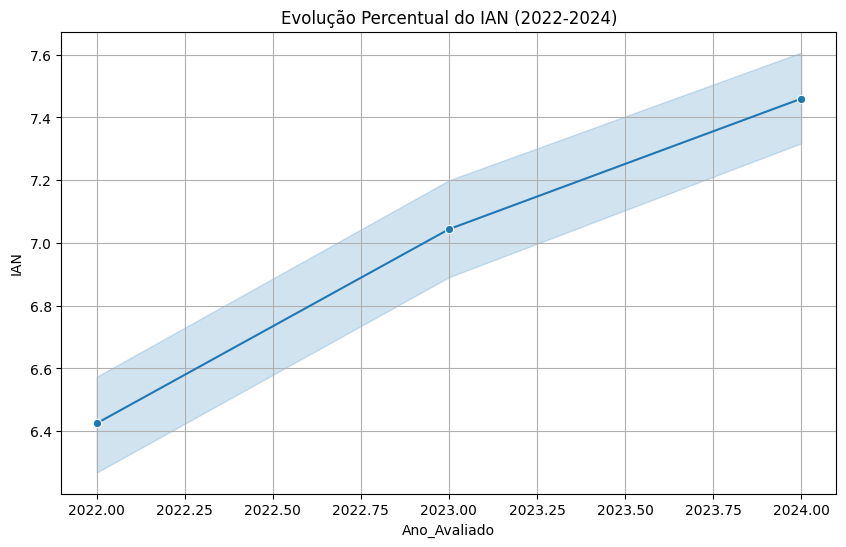

In [44]:
# criando gráfico para avaliar a evolução
plt.figure(figsize=(10,6))
sns.lineplot(data=df, x='Ano_Avaliado', y='IAN', marker='o')

plt.title('Evolução Percentual do IAN (2022-2024)')
plt.grid(True)
plt.show()

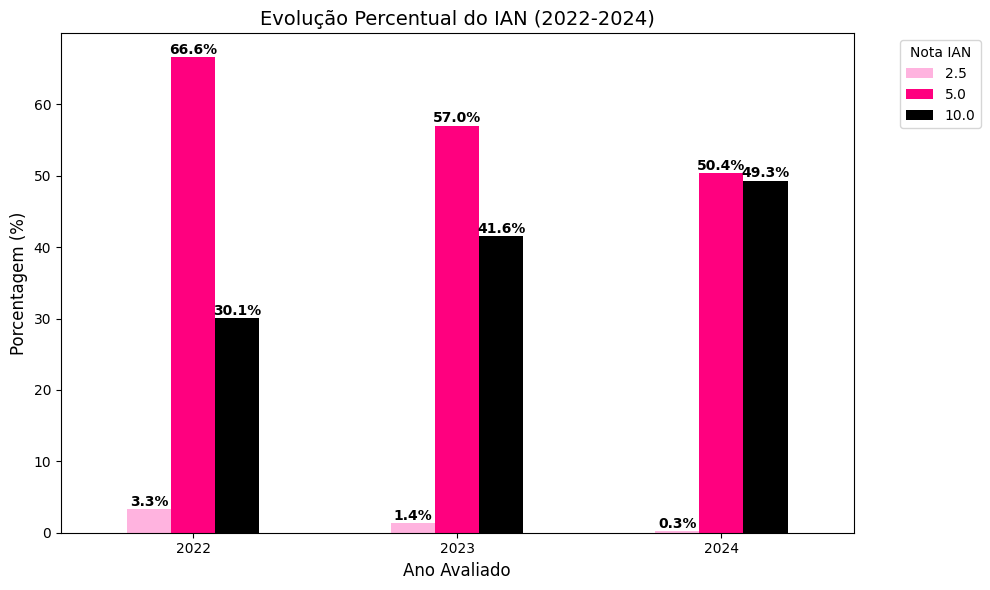

In [45]:
# Criando o gráfico de comparação

# fazendo com que cada ano some 100%
tabela_pct = pd.crosstab(df['Ano_Avaliado'], df['IAN'], normalize='index')*100

# gerar o gráfico
ax = tabela_pct.plot(kind='bar', figsize=(10,6),
                     color=['#ffb3df','#ff007f','#000000'])

# Formatando o Gráfico
plt.title('Evolução Percentual do IAN (2022-2024)', fontsize=14)
plt.xlabel('Ano Avaliado', fontsize=12)
plt.ylabel('Porcentagem (%)', fontsize=12)
plt.legend(title = 'Nota IAN', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)

# adicionar rótulo de dados
for p in ax.patches:
  width, height = p.get_width(), p.get_height()
  x, y = p.get_xy()
  if height > 0.1: # Só desenha se a fatia for visível (> 2%)
        ax.annotate(f'{height:.1f}%', (x + width/2, y + height+1),
                    ha='center', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

Avaliando o gráfico conseguimos perceber que o perfil de defasagem dos alunos reduz ao longo dos anos. Conseguimos perceber que há redução na motas 2,5 e 5,0 ao longo dos anos e há o aumento das notas 10 neste período. Vemos que notas 10 em 2022 era apenas 30% contra 67% das notas 5,0, já no ano de 2024 vemos que estão próximos, 49,3% para notas 10 contra 50,4% de notas 5,0. Logo, se continuar esta tendência, no próximo ano devemos ter a quantidade de notas 10
ultrapassando a de notas 5,0

## 2. Desempenho acadêmico (IDA): O desempenho acadêmico médio (IDA) está melhorando, estagnado ou caindo ao longo das fases e anos?

In [46]:
# gerando a média anual

IDA_media = round(df.groupby('Ano_Avaliado')['IDA'].mean(),2)
IDA_media

,IDA
Ano_Avaliado,
2022,6.09
2023,6.67
2024,6.35


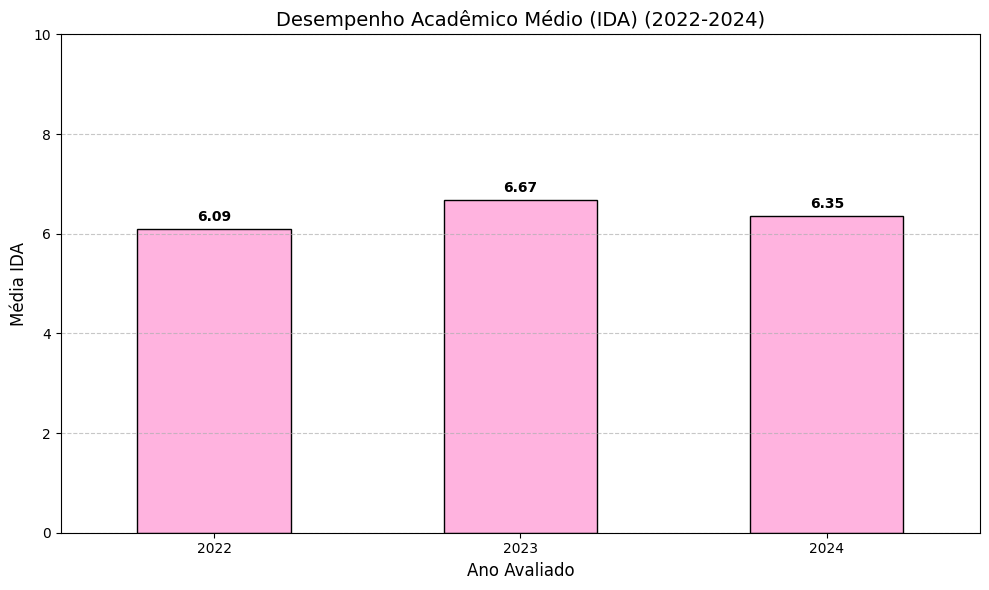

In [47]:
# Criando o gráfico de comparação

# gerar o gráfico
ax = IDA_media.plot(kind='bar', figsize=(10,6), color='#ffb3df', edgecolor='black')

# Formatando o Gráfico
plt.title('Desempenho Acadêmico Médio (IDA) (2022-2024)', fontsize=14)
plt.xlabel('Ano Avaliado', fontsize=12)
plt.ylabel('Média IDA', fontsize=12)
plt.xticks(rotation=0) # Mantém o texto do ano na horizontal
plt.grid(axis='y', linestyle='--', alpha=0.7) #linhas de grade apenas no eixo y

# adicionar rótulo de dados
for p in ax.patches:
  ax.annotate(str(p.get_height()),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0,9),
                textcoords = 'offset points',
                fontsize=10, fontweight='bold')

# ajustar o limito do eixo Y para os números não ficarem cortados
plt.ylim(0, 10)

plt.tight_layout()
plt.show()

Analisando as notas, a percepção é de que o desempenho acadêmico está estagnado. Houve melhora de 2022 para 2023 porém voltou a cair em 2024, mas sempre entre 6 e 7

## 3. Engajamento nas atividades (IEG): O grau de engajamento dos alunos (IEG) tem relação direta com seus indicadores de desempenho (IDA) e do ponto de virada (IPV)?

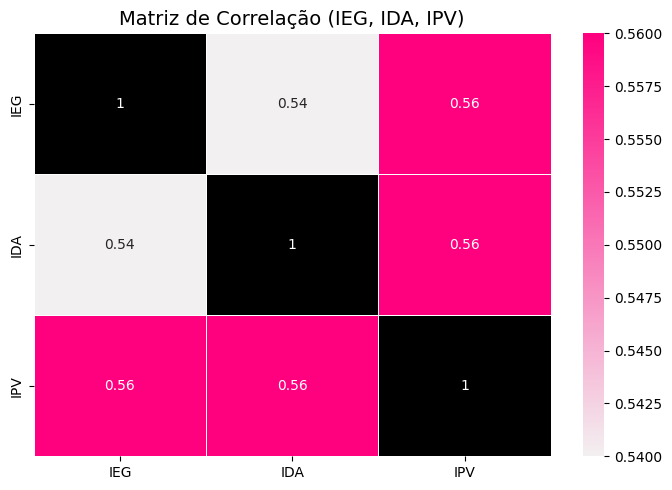

In [48]:
# Fazendo a correlação entre as colunas
colunas_foco = ['IEG', 'IDA', 'IPV']
correlation_matrix = df[colunas_foco].corr(numeric_only=True).round(2)

# A nossa paleta Rosa baseada na sua cor (#ff007f)
minha_paleta = sns.light_palette("#ff007f", as_cmap=True)

fig, ax = plt.subplots(figsize=(7,5))

# 1. Criando a máscara que identifica a diagonal (matriz 3x3)
mascara = np.eye(len(correlation_matrix), dtype=bool)

# 2. Camada Base: O heatmap rosa com a diagonal escondida
sns.heatmap(data=correlation_matrix, annot=True, linewidths=.5, ax=ax,
            cmap=minha_paleta, mask=mascara)

# 3. Camada Superior: Apenas a diagonal pintada de preto
sns.heatmap(data=correlation_matrix, annot=True, linewidths=.5, ax=ax,
            cmap=ListedColormap(['black']), mask=~mascara, cbar=False)

# Adicionando o título
plt.title('Matriz de Correlação (IEG, IDA, IPV)', fontsize=14)
plt.tight_layout()
plt.show()

Conseguimos avaliar utilizando correlação que existe uma relação entre estes indicadores.

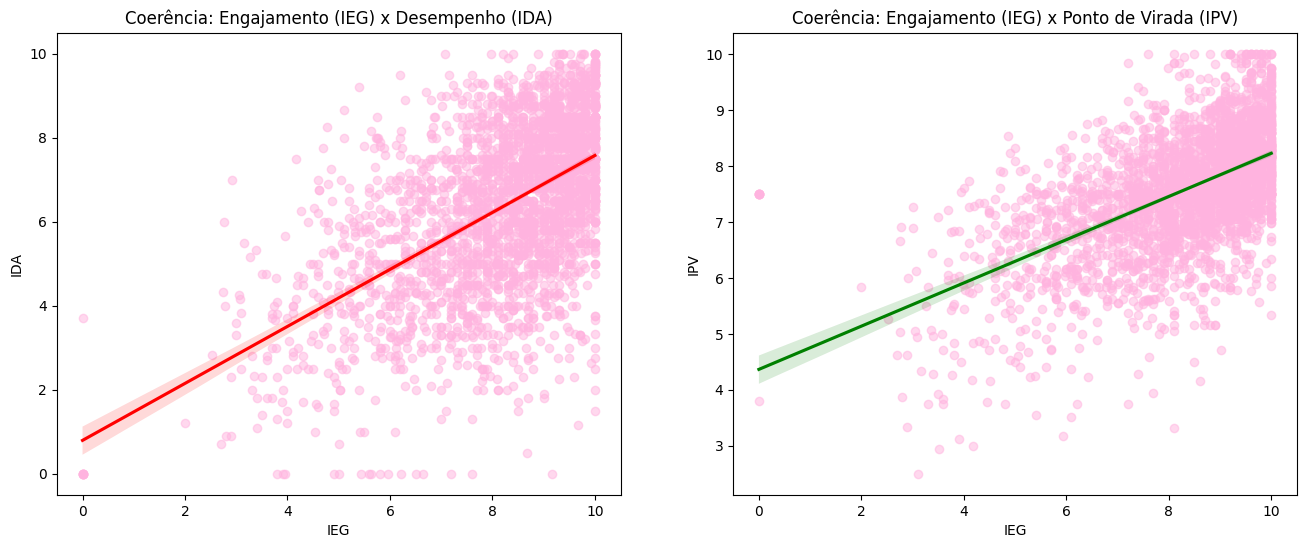

In [49]:
# Criando uma visualização por gráfico de dispersão
# gráficos lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,6))

# Gráfico 1: IEG x IDA
sns.regplot(data=df, x='IEG', y='IDA', ax=ax1, scatter_kws={'alpha':0.5, 'color': '#ffb3df'}, line_kws={'color':'red'})
ax1.set_title('Coerência: Engajamento (IEG) x Desempenho (IDA)')

# Gráfico 2: IEG x IPV
sns.regplot(data=df, x='IEG', y='IPV', ax=ax2, scatter_kws={'alpha':0.5, 'color': '#ffb3df'}, line_kws={'color':'green'})
ax2.set_title('Coerência: Engajamento (IEG) x Ponto de Virada (IPV)')

plt.show()

Avaliando o gráfico de dispersão, conseguimos ver que existe uma relação entre os indicadores, de forma positiva, ou seja, quanto maior um, maior o outro

## 4. Autoavaliação (IAA): As percepções dos alunos sobre si mesmos (IAA) são coerentes com seu desempenho real (IDA) e engajamento (IEG)?

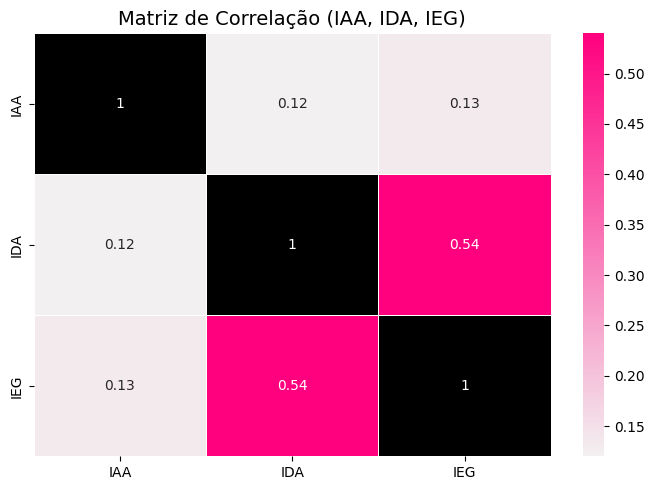

In [50]:
# Fazendo a correlação entre as colunas
colunas_foco = ['IAA', 'IDA', 'IEG']
correlation_matrix = df[colunas_foco].corr(numeric_only=True).round(2)

# A nossa paleta Rosa baseada na sua cor (#ff007f)
minha_paleta = sns.light_palette("#ff007f", as_cmap=True)

fig, ax = plt.subplots(figsize=(7,5))

# 1. Criando a máscara que identifica a diagonal (matriz 3x3)
mascara = np.eye(len(correlation_matrix), dtype=bool)

# 2. Camada Base: O heatmap rosa com a diagonal escondida
sns.heatmap(data=correlation_matrix, annot=True, linewidths=.5, ax=ax,
            cmap=minha_paleta, mask=mascara)

# 3. Camada Superior: Apenas a diagonal pintada de preto
sns.heatmap(data=correlation_matrix, annot=True, linewidths=.5, ax=ax,
            cmap=ListedColormap(['black']), mask=~mascara, cbar=False)

# Adicionando o título
plt.title('Matriz de Correlação (IAA, IDA, IEG)', fontsize=14)
plt.tight_layout()
plt.show()

Analisando o resultado da correlação entre IAA com IDA e IEG, percebemos que a correlação está abaixo de 0.2, ou seja a percepção dos alunos perante o seu próprio desempenho não condiz a realidade

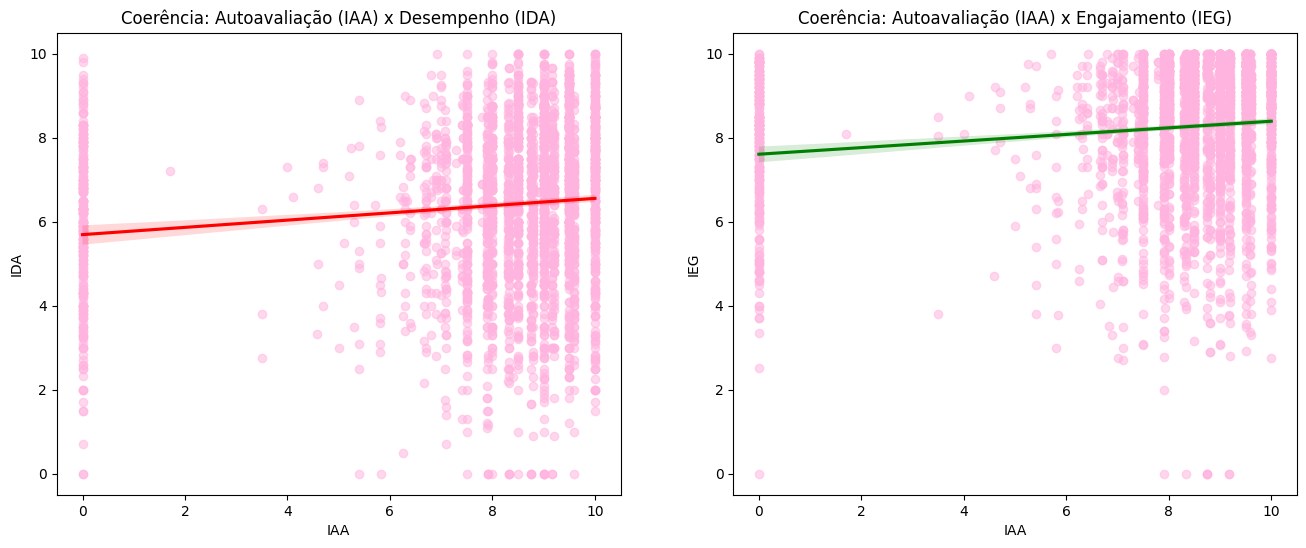

In [51]:
# Criando uma visualização por gráfico de dispersão
# gráficos lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,6))

# Gráfico 1: IAA x IDA
sns.regplot(data=df, x='IAA', y='IDA', ax=ax1, scatter_kws={'alpha':0.5, 'color': '#ffb3df'}, line_kws={'color':'red'})
ax1.set_title('Coerência: Autoavaliação (IAA) x Desempenho (IDA)')

# Gráfico 2: IAA x IEG
sns.regplot(data=df, x='IAA', y='IEG', ax=ax2, scatter_kws={'alpha':0.5, 'color': '#ffb3df'}, line_kws={'color':'green'})
ax2.set_title('Coerência: Autoavaliação (IAA) x Engajamento (IEG)')

plt.show()

Olhando os gráficos conseguimos visualmente perceber que não há relação entre eles, ou seja, a autoavaliação dos alunos não condiz com a realidade

## 5. Aspectos psicossociais (IPS): Há padrões psicossociais (IPS) que antecedem quedas de desempenho acadêmico (IDA) ou de engajamento (IEG)?


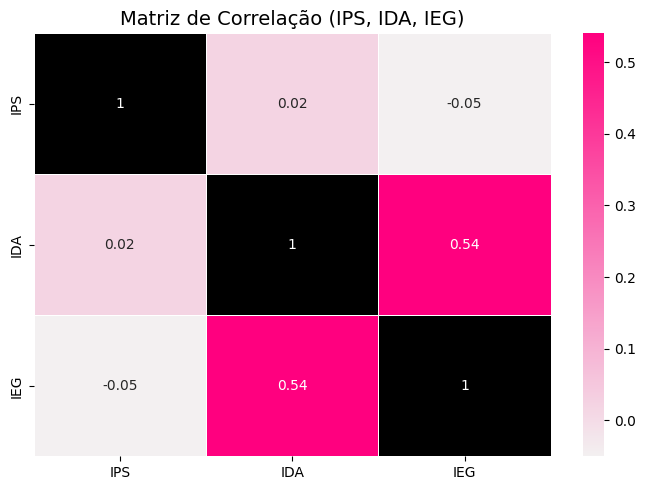

In [52]:
# Fazendo a correlação entre as colunas
colunas_foco = ['IPS', 'IDA', 'IEG']
correlation_matrix = df[colunas_foco].corr(numeric_only=True).round(2)

# A nossa paleta Rosa baseada na sua cor (#ff007f)
minha_paleta = sns.light_palette("#ff007f", as_cmap=True)

fig, ax = plt.subplots(figsize=(7,5))

# 1. Criando a máscara que identifica a diagonal (matriz 3x3)
mascara = np.eye(len(correlation_matrix), dtype=bool)

# 2. Camada Base: O heatmap rosa com a diagonal escondida
sns.heatmap(data=correlation_matrix, annot=True, linewidths=.5, ax=ax,
            cmap=minha_paleta, mask=mascara)

# 3. Camada Superior: Apenas a diagonal pintada de preto
sns.heatmap(data=correlation_matrix, annot=True, linewidths=.5, ax=ax,
            cmap=ListedColormap(['black']), mask=~mascara, cbar=False)

# Adicionando o título para fechar com chave de ouro
plt.title('Matriz de Correlação (IPS, IDA, IEG)', fontsize=14)
plt.tight_layout()
plt.show()

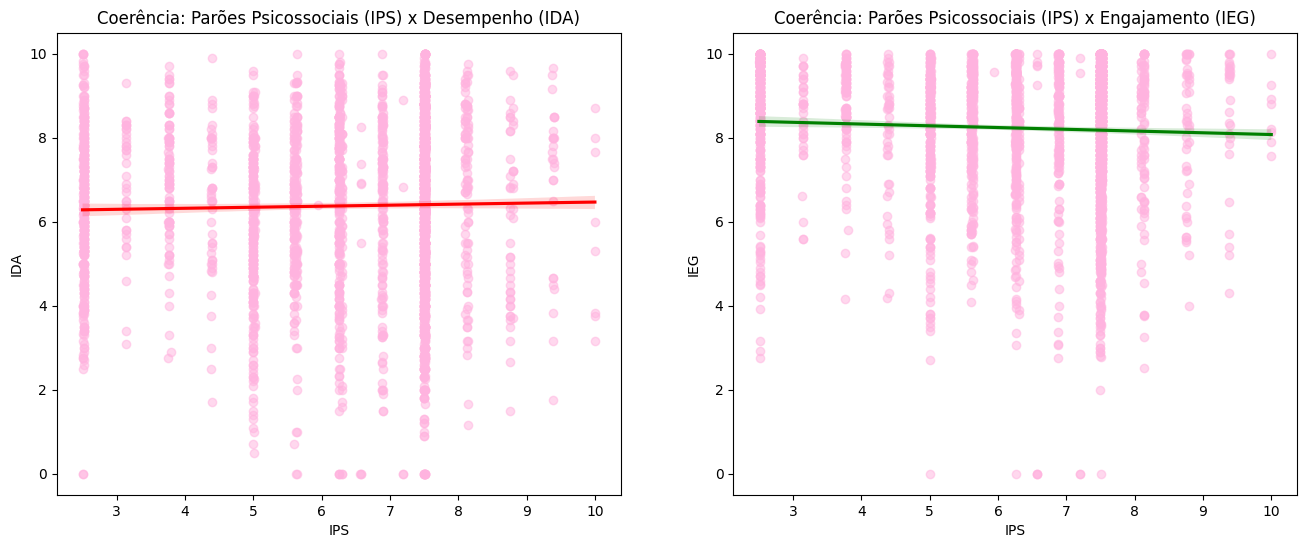

In [53]:
# Criando uma visualização por gráfico de dispersão
# gráficos lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,6))

# Gráfico 1: IAA x IDA
sns.regplot(data=df, x='IPS', y='IDA', ax=ax1, scatter_kws={'alpha':0.5, 'color': '#ffb3df'}, line_kws={'color':'red'})
ax1.set_title('Coerência: Parões Psicossociais (IPS) x Desempenho (IDA)')

# Gráfico 2: IAA x IEG
sns.regplot(data=df, x='IPS', y='IEG', ax=ax2, scatter_kws={'alpha':0.5, 'color': '#ffb3df'}, line_kws={'color':'green'})
ax2.set_title('Coerência: Parões Psicossociais (IPS) x Engajamento (IEG)')

plt.show()

Avaliando tando a matriz de correlação quanto os gráficos de dispersão, conseguimos perceber que não é possível dizer que existe uma relação direta entre padrões psicossociais e desempenho ou engajamento. Ou seja, não é possível prever utilizando apenas padrões psicossociais

## 6. Aspectos psicopedagógicos (IPP): As avaliações psicopedagógicas (IPP) confirmam ou contradizem a defasagem identificada pelo IAN?


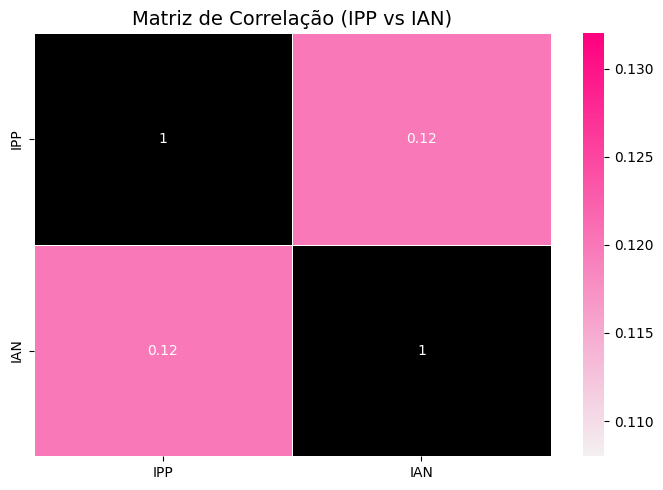

In [54]:
# Fazendo a correlação entre as colunas
colunas_foco = ['IPP', 'IAN']
correlation_matrix = df[colunas_foco].corr(numeric_only=True).round(2)

# A nossa paleta Rosa baseada na sua cor
minha_paleta = sns.light_palette("#ff007f", as_cmap=True)

fig, ax = plt.subplots(figsize=(7,5))

# 1. Criando a máscara que identifica a diagonal (agora para matriz 2x2)
mascara = np.eye(len(correlation_matrix), dtype=bool)

# 2. Camada Base: O heatmap rosa com a diagonal escondida
sns.heatmap(data=correlation_matrix, annot=True, linewidths=.5, ax=ax,
            cmap=minha_paleta, mask=mascara)

# 3. Camada Superior: Apenas a diagonal pintada de preto
sns.heatmap(data=correlation_matrix, annot=True, linewidths=.5, ax=ax,
            cmap=ListedColormap(['black']), mask=~mascara, cbar=False)

# Adicionando um título claro para o slide
plt.title('Matriz de Correlação (IPP vs IAN)', fontsize=14)
plt.tight_layout()
plt.show()

Não existe uma relação entre elas, então não é possível avaliar se os aspectos psicopedagógicos confirmar ou contradizem a defasagem identificada.

Text(0.5, 1.0, 'Coerência: Aspectos Psicopedagógicos (IPP) x Defasagem (IAN)')

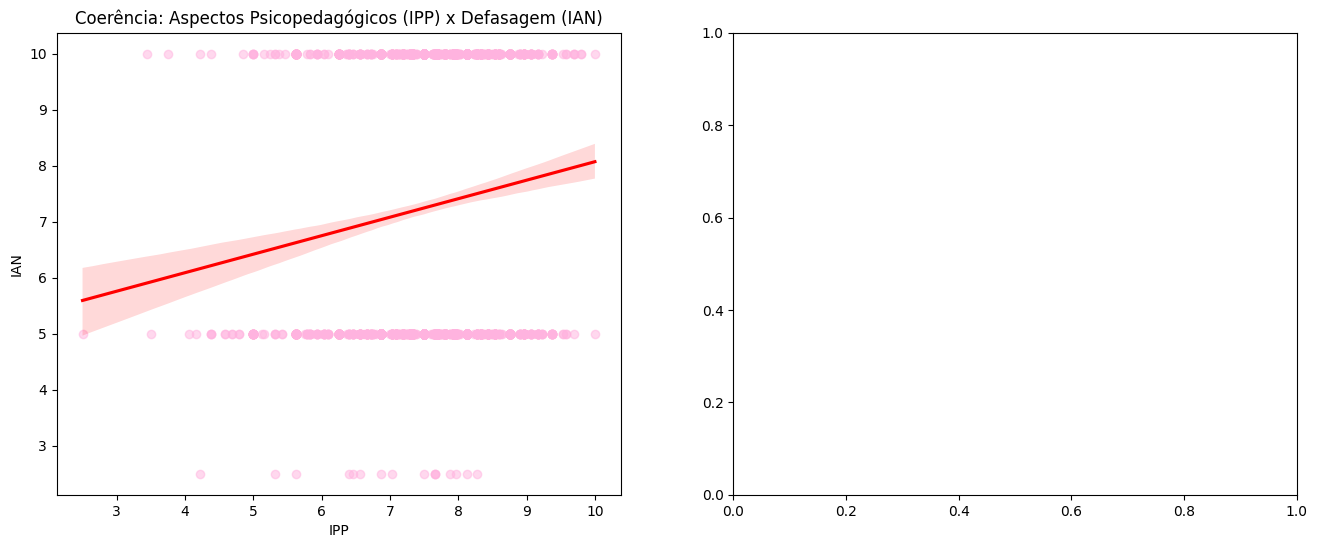

In [55]:
# Criando uma visualização por gráfico de dispersão
# gráficos lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,6))

# Gráfico 1: IAA x IDA
sns.regplot(data=df, x='IPP', y='IAN', ax=ax1, scatter_kws={'alpha':0.5, 'color': '#ffb3df'}, line_kws={'color':'red'})
ax1.set_title('Coerência: Aspectos Psicopedagógicos (IPP) x Defasagem (IAN)')

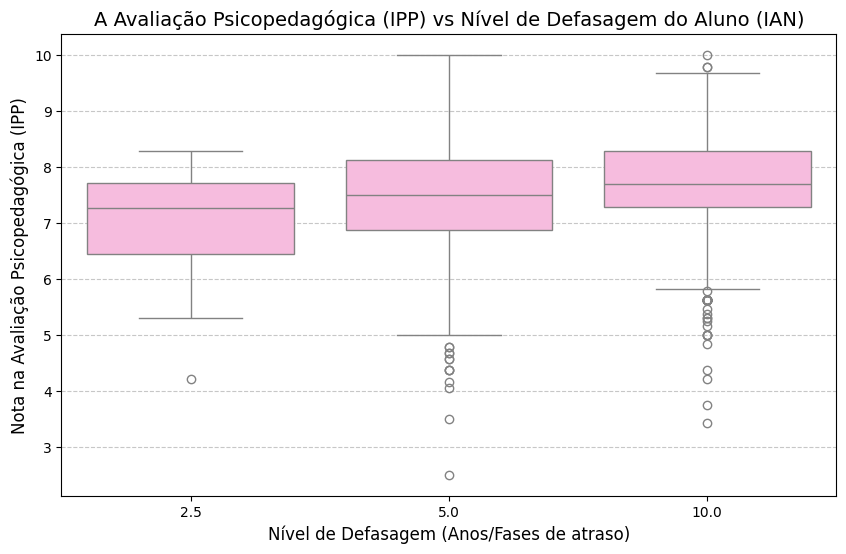

In [56]:
plt.figure(figsize=(10, 6))

# Trocamos palette='viridis' por color='#ffb3df'
# Agora todas as caixas serão deste tom de rosa
sns.boxplot(x='IAN', y='IPP', data=df, color='#ffb3df')

plt.title('A Avaliação Psicopedagógica (IPP) vs Nível de Defasagem do Aluno (IAN)', fontsize=14)
plt.xlabel('Nível de Defasagem (Anos/Fases de atraso)', fontsize=12)
plt.ylabel('Nota na Avaliação Psicopedagógica (IPP)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Mostrar o gráfico no ecrã
plt.show()

Analisando o Boxplot não conseguimos perceber um relação de confirmação do aspectos psicopedagógicos em relação ao índice de defasagem.

Segundo a avaliação,

*   2,5 corresponde a uma defasagem severa
*   5 corresponde a uma defasagem moderada
*   10 corresponde a uma defasagem exata - sem defasagem

comparando com as notas de avaliações psicopedagógicas (IPP) não existe uma grande variação dos dados. Apesar de vermos uma crescente no IPP conforme a defasagem reduz, as medianas então muito próximas entre si. E existe bastente outliers principalmente nas defasagens 5 e 10


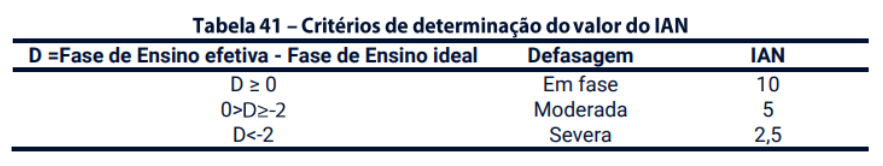



Alunos antes do corte: 1985
Alunos DEPOIS do corte: 1922
Total de outliers removidos: 63


/tmp/ipykernel_1051/1958523263.py:36: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_limpo = df_outlier.groupby('IAN').apply(remover_outliers).reset_index(drop=True)


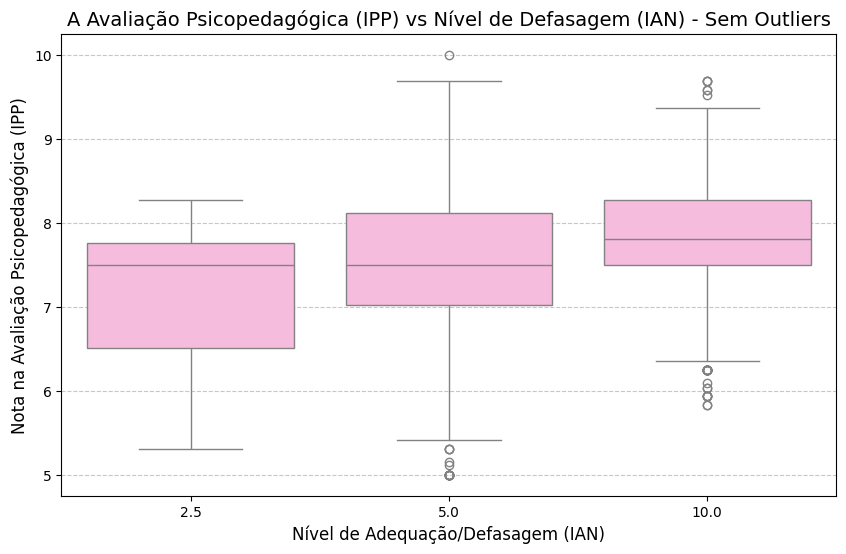

In [57]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# 1. Carregar e Preparar a Base
# ==========================================
df_outlier = df[['IAN', 'IPP']].copy()

# Converter vírgula para ponto e remover alunos sem nota
for col in ['IAN', 'IPP']:
    if df_outlier[col].dtype == object:
        df_outlier[col] = pd.to_numeric(df_outlier[col].str.replace(',', '.'), errors='coerce')
df_outlier.dropna(inplace=True)

# ==========================================
# 2. A Lógica Matemática de Remoção (Método IQR)
# ==========================================
# Vamos criar uma função que olha para cada grupo do IAN e corta os extremos do IPP
def remover_outliers(grupo):
    Q1 = grupo['IPP'].quantile(0.25) # Onde começa o bloco principal (25%)
    Q3 = grupo['IPP'].quantile(0.75) # Onde termina o bloco principal (75%)
    IQR = Q3 - Q1                    # O tamanho da caixa principal

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    # Retorna apenas os alunos que estão DENTRO do limite normal
    filtro = (grupo['IPP'] >= limite_inferior) & (grupo['IPP'] <= limite_superior)
    return grupo[filtro]

# ==========================================
# 3. Aplicando a Limpeza Real na Tabela
# ==========================================
# Agrupamos pelo IAN para respeitar a média de cada grupo e aplicamos a tesoura!
df_limpo = df_outlier.groupby('IAN').apply(remover_outliers).reset_index(drop=True)

# Opcional: Mostrar quantos alunos foram removidos
print(f"Alunos antes do corte: {len(df_outlier)}")
print(f"Alunos DEPOIS do corte: {len(df_limpo)}")
print(f"Total de outliers removidos: {len(df_outlier) - len(df_limpo)}")

# ==========================================
# 4. Refazer o Gráfico com os Dados Limpos
# ==========================================
plt.figure(figsize=(10, 6))

# Atenção: Passamos agora o df_limpo! Não usamos mais o showfliers=False
sns.boxplot(x='IAN', y='IPP', data=df_limpo, color='#ffb3df')

plt.title('A Avaliação Psicopedagógica (IPP) vs Nível de Defasagem (IAN) - Sem Outliers', fontsize=14)
plt.xlabel('Nível de Adequação/Defasagem (IAN)', fontsize=12)
plt.ylabel('Nota na Avaliação Psicopedagógica (IPP)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Mostrar o gráfico no ecrã
plt.show()

Avaliando sem os Outliers consegimos ver que as medianas estão ainda mais próximas, logo podemos concluir que IPP e IAN não se relacionam.

## 7. Ponto de virada (IPV): Quais comportamentos - acadêmicos, emocionais ou de engajamento - mais influenciam o IPV ao longo do tempo?

Para entender quais comportamentos mais influenciam, precisamos fazer a correlação deles com o IPV para entender se existe alguma

*   IDA - Desempenho Acadêmico
*   IPS - Indicador Psicossocial (Emocionais)
*   IEG - Engajamento

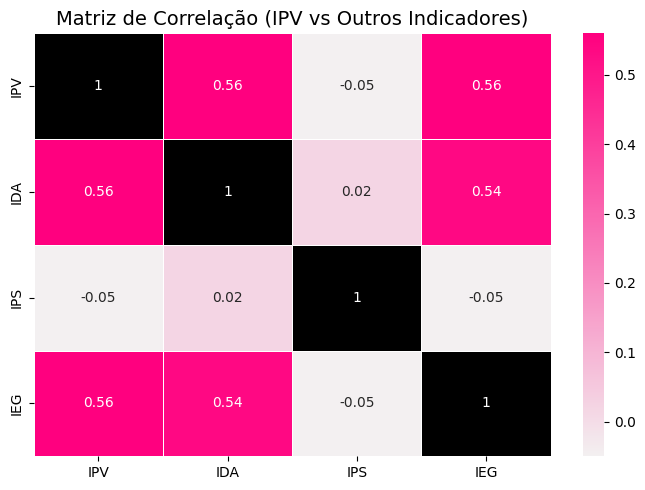

In [58]:
# Matriz de correlação com as novas colunas
colunas_foco = ['IPV', 'IDA', 'IPS', 'IEG']
correlation_matrix = df[colunas_foco].corr(numeric_only=True).round(2)

# Criando a paleta Rosa baseada na sua cor
minha_paleta = sns.light_palette("#ff007f", as_cmap=True)

fig, ax = plt.subplots(figsize=(7,5))

# 1. Criando a máscara que identifica a diagonal (agora para matriz 4x4)
mascara = np.eye(len(correlation_matrix), dtype=bool)

# 2. Camada Base: O heatmap rosa com a diagonal escondida
sns.heatmap(data=correlation_matrix, annot=True, linewidths=.5, ax=ax,
            cmap=minha_paleta, mask=mascara)

# 3. Camada Superior: Apenas a diagonal pintada de preto
sns.heatmap(data=correlation_matrix, annot=True, linewidths=.5, ax=ax,
            cmap=ListedColormap(['black']), mask=~mascara, cbar=False)

plt.title('Matriz de Correlação (IPV vs Outros Indicadores)', fontsize=14)
plt.tight_layout()
plt.show()

Avaliando a matrix, podemos ver que indicador de desempenho acadêmico e de engajamento são os que mais influenciam o Ponto de Virada. Eles atuam de forma positiva, quanto maior os indicadores, maior o ponto de virada.

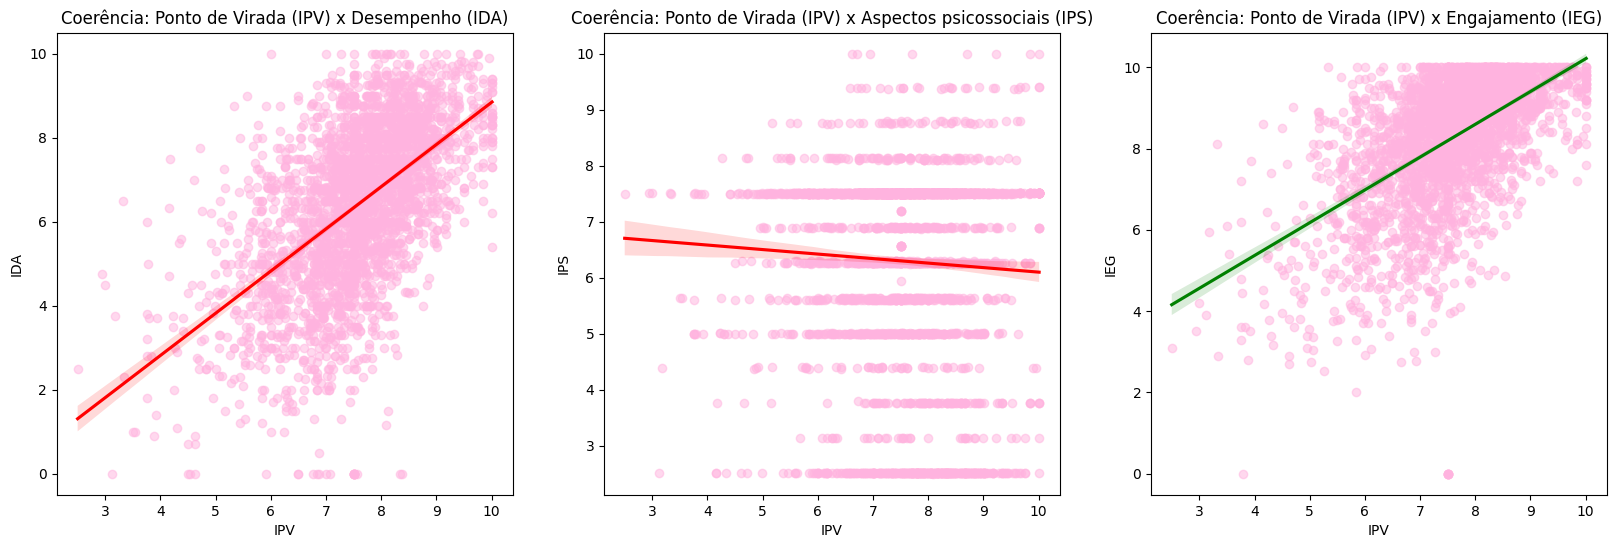

In [59]:
# Criando uma visualização por gráfico de dispersão
# gráficos lado a lado
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20,6))

# Gráfico 1: IPV x IDA
sns.regplot(data=df, x='IPV', y='IDA', ax=ax1, scatter_kws={'alpha':0.5, 'color': '#ffb3df'}, line_kws={'color':'red'})
ax1.set_title('Coerência: Ponto de Virada (IPV) x Desempenho (IDA)')

# Gráfico 1: IAA x IDA
sns.regplot(data=df, x='IPV', y='IPS', ax=ax2, scatter_kws={'alpha':0.5, 'color': '#ffb3df'}, line_kws={'color':'red'})
ax2.set_title('Coerência: Ponto de Virada (IPV) x Aspectos psicossociais (IPS)')

# Gráfico 2: IAA x IEG
sns.regplot(data=df, x='IPV', y='IEG', ax=ax3, scatter_kws={'alpha':0.5, 'color': '#ffb3df'}, line_kws={'color':'green'})
ax3.set_title('Coerência: Ponto de Virada (IPV) x Engajamento (IEG)')

plt.show()

Olhando os gráficos, conseguimos ver que IDA e IEG tem relação com o IPV

## 8. Multidimensionalidade dos indicadores: Quais combinações de indicadores (IDA + IEG + IPS + IPP) elevam mais a nota global do aluno (INDE)?

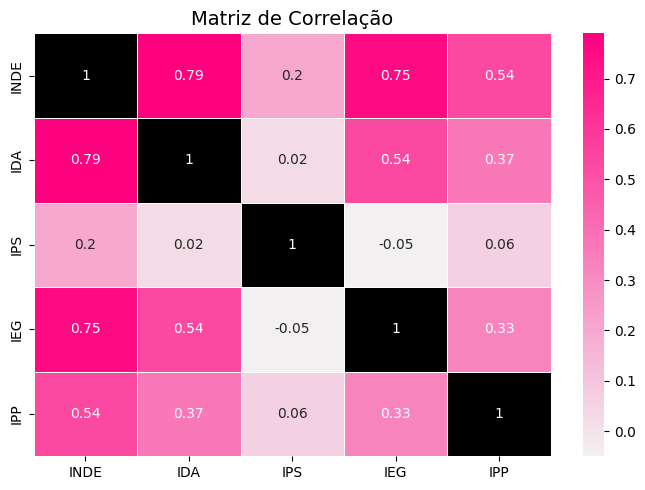

In [60]:
# Matriz de correlação
# Matriz de correlação
colunas_foco = ['INDE', 'IDA', 'IPS', 'IEG', 'IPP']
correlation_matrix = df[colunas_foco].corr(numeric_only=True).round(2)

# A sua paleta personalizada (Rosa/Magenta claro para escuro)
minha_paleta = sns.light_palette("#ff007f", as_cmap=True)

fig, ax = plt.subplots(figsize=(7,5))

# 1. A Mágica: Criando a máscara para a diagonal
mascara = np.eye(len(correlation_matrix), dtype=bool)

# 2. Camada Base: O seu heatmap rosa (escondendo a diagonal com mask=mascara)
sns.heatmap(data=correlation_matrix, annot=True, linewidths=.5, ax=ax,
            cmap=minha_paleta, mask=mascara)

# 3. Camada Superior: Apenas a diagonal em preto (escondendo o resto com mask=~mascara)
sns.heatmap(data=correlation_matrix, annot=True, linewidths=.5, ax=ax,
            cmap=ListedColormap(['black']), mask=~mascara, cbar=False)

# Título opcional para dar o toque final
plt.title('Matriz de Correlação', fontsize=14)
plt.tight_layout()
plt.show()

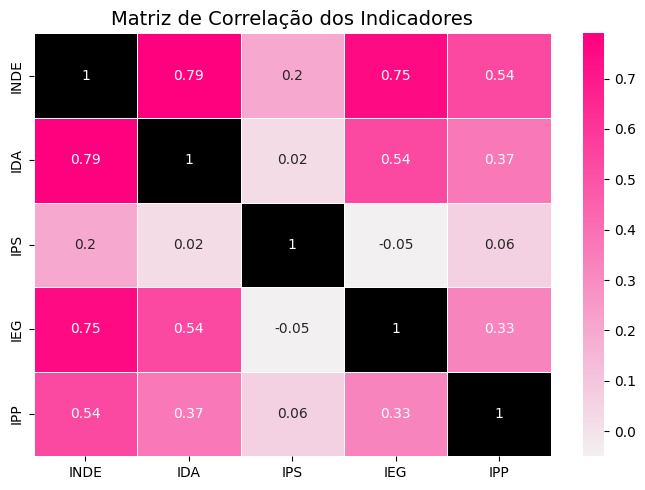

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import ListedColormap

# Matriz de correlação
colunas_foco = ['INDE', 'IDA', 'IPS', 'IEG', 'IPP']
correlation_matrix = df[colunas_foco].corr(numeric_only=True).round(2)

fig, ax = plt.subplots(figsize=(7,5))

# Criando a paleta Rosa
minha_paleta = sns.light_palette("#ff007f", as_cmap=True)

# O TRUQUE: Criando a máscara que identifica a diagonal (linha reta de 1s)
# np.eye cria uma matriz com Verdadeiro na diagonal e Falso no resto
mascara_diagonal = np.eye(len(correlation_matrix), dtype=bool)

# Camada 1: Plota o gráfico rosa, mas ESCONDE a diagonal (mask=mascara_diagonal)
sns.heatmap(data=correlation_matrix, annot=True, linewidths=.5, ax=ax,
            cmap=minha_paleta, mask=mascara_diagonal)

# Camada 2: Plota de novo por cima, mas agora esconde o resto e MOSTRA a diagonal (mask=~mascara_diagonal)
# Usamos um ListedColormap para forçar a cor 'black' (preta) nessas células
# cbar=False evita que o Python desenhe a régua de cores duas vezes na lateral
sns.heatmap(data=correlation_matrix, annot=True, linewidths=.5, ax=ax,
            cmap=ListedColormap(['black']), mask=~mascara_diagonal, cbar=False)

plt.title('Matriz de Correlação dos Indicadores', fontsize=14)
plt.tight_layout()
plt.show()

Olhando a matriz de correlação, a combinação IDA + IEG são as que mais influenciam o INDE

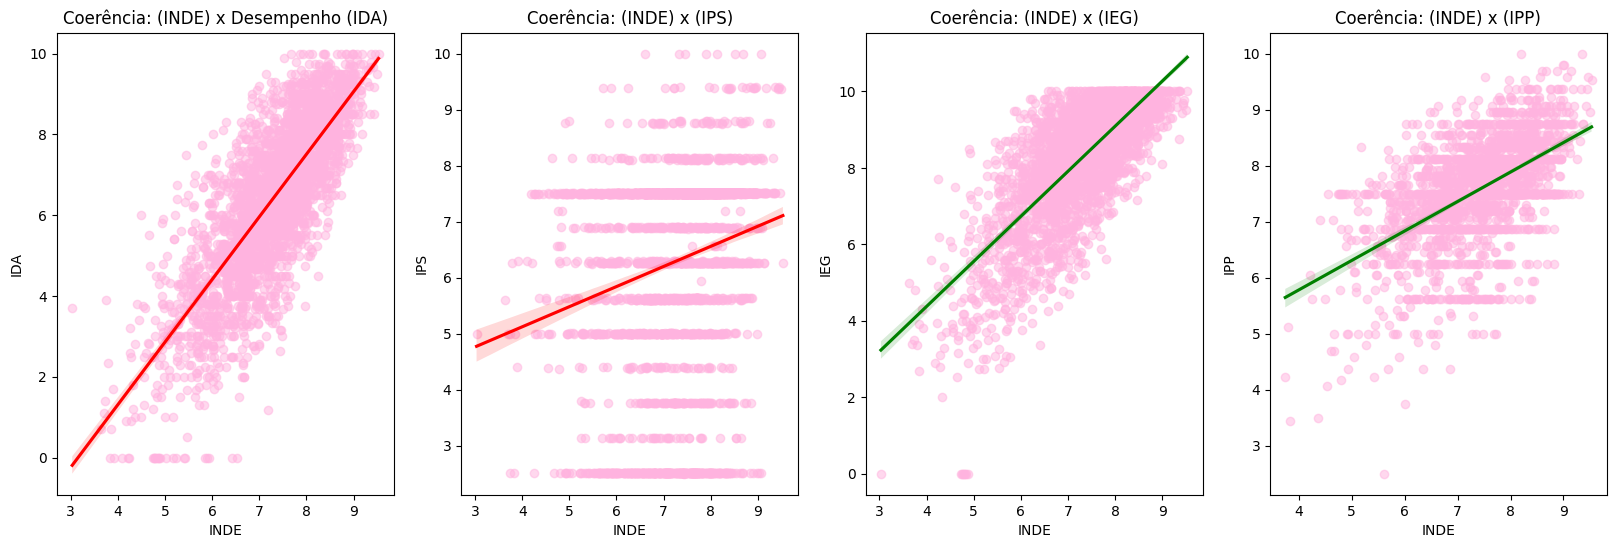

In [62]:
# Criando uma visualização por gráfico de dispersão
# gráficos lado a lado
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(20,6))

# Gráfico 1: IPV x IDA
sns.regplot(data=df, x='INDE', y='IDA', ax=ax1, scatter_kws={'alpha':0.5, 'color': '#ffb3df'}, line_kws={'color':'red'})
ax1.set_title('Coerência: (INDE) x Desempenho (IDA)')

# Gráfico 1: IAA x IDA
sns.regplot(data=df, x='INDE', y='IPS', ax=ax2, scatter_kws={'alpha':0.5, 'color': '#ffb3df'}, line_kws={'color':'red'})
ax2.set_title('Coerência: (INDE) x (IPS)')

# Gráfico 2: IAA x IEG
sns.regplot(data=df, x='INDE', y='IEG', ax=ax3, scatter_kws={'alpha':0.5, 'color': '#ffb3df'}, line_kws={'color':'green'})
ax3.set_title('Coerência: (INDE) x (IEG)')

# Gráfico 2: IAA x IEG
sns.regplot(data=df, x='INDE', y='IPP', ax=ax4, scatter_kws={'alpha':0.5, 'color': '#ffb3df'}, line_kws={'color':'green'})
ax4.set_title('Coerência: (INDE) x (IPP)')

plt.show()

## 10. Efetividade do programa: Os indicadores mostram melhora consistente ao longo do ciclo nas diferentes fases (Quartzo, Ágata, Ametista e Topázio), confirmando o impacto real do programa?

In [63]:
# Substituindo a palavra 'Ágata' por 'Agata' na coluna 'Pedra'
df['Pedra'] = df['Pedra'].replace('Ágata', 'Agata')

In [64]:
# gerando a contagem anual

PEDRA_count = df.groupby('Ano_Avaliado')['Pedra'].value_counts()
PEDRA_count

Ano_Avaliado  Pedra   
2022          Ametista    348
              Agata       250
              Quartzo     132
              Topázio     130
2023          Ametista    381
              Agata       246
              Topázio     232
              Quartzo      72
2024          Ametista    391
              Topázio     326
              Agata       225
              Quartzo     112
Name: count, dtype: int64

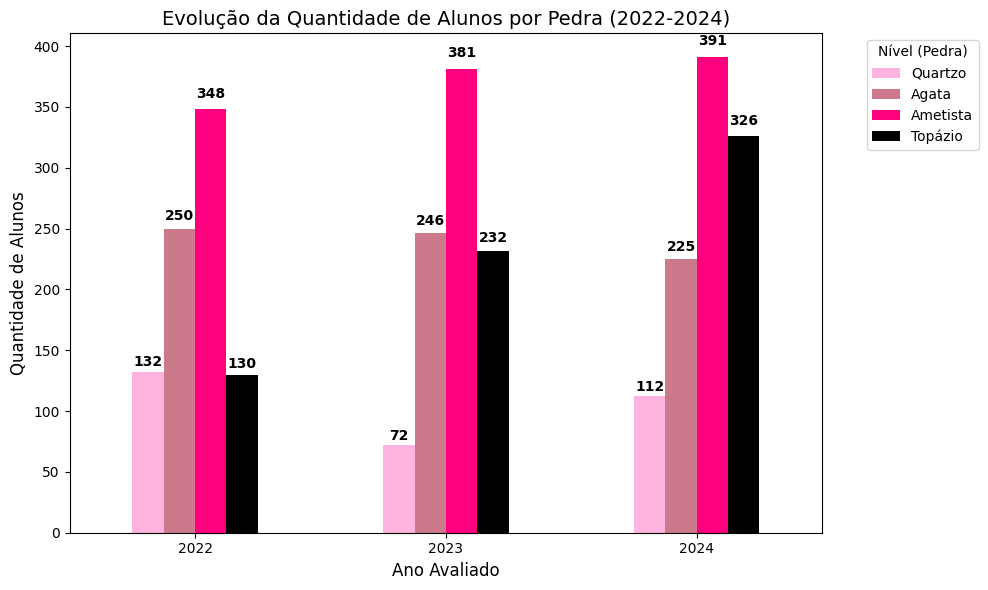

In [65]:
# Criando o gráfico de comparação

# 1. Tabela de Contagem Absoluta
tabela_pedra = pd.crosstab(df['Ano_Avaliado'], df['Pedra'])

# 2. A MÁGICA DA ORDENAÇÃO: Forçamos a ordem das colunas da tabela
ordem_correta = ['Quartzo', 'Agata', 'Ametista', 'Topázio']

# Usamos apenas as colunas que estão na nossa lista (e na ordem dela)
tabela_pedra = tabela_pedra[ordem_correta]

# 3. Gerar o gráfico com as cores alinhadas com as pedras
# Verde (Quartzo), Azul (Agata), Roxo (Ametista) e Laranja (Topázio)
ax = tabela_pedra.plot(kind='bar', figsize=(10,6),
                     color=['#ffb3df', '#cc7a8b', '#ff007f', '#000000'])

# 4. Formatando o Gráfico
plt.title('Evolução da Quantidade de Alunos por Pedra (2022-2024)', fontsize=14)
plt.xlabel('Ano Avaliado', fontsize=12)
plt.ylabel('Quantidade de Alunos', fontsize=12)
plt.legend(title='Nível (Pedra)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)

# 5. Adicionar rótulo de dados em números inteiros
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()

    if height > 0: # Só desenha se tiver pelo menos 1 aluno naquela barra
        ax.annotate(f'{int(height)}',
                    (x + width/2, y + height * 1.02),
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

Verificamos através dos gráficos que os indicadores mostram evolução ao longo dos anos tanto do INDE médio como da composição do quantitativo de alunos por fase. Houve aumento significativo do quantitativo de alunos nas fases de maiores INDEs, como Ametista e Topázio e redução dos alunos nas fases Quartzo e Agata, apesar de significativo aumento no quantitativo de alunos na fase Quartzo de 2023 para 2024.

Conseguimos percemer melhora dos alunos no programa. Mesmo com a entrada de alunos ao longo dos anos, percemos que Quartzo, o nível de entrada ainda ficou menor que 2022. Vemos que Agata, teve uma leve redução nos alunos desta categoria. E por fim conseguimos perceber que os dois últmos níveis, Ametista e Topázio ouve um aumento de alunos nestas categorias. No Topázio é ainda mais acentuado, com crescimentos de 77% de 2022 para 2023 e de 40% de 2023 para 2024.

## 11. Insights e criatividade: Você pode adicionar mais insights e pontos de vista não abordados nas perguntas, utilize a criatividade e a análise dos dados para trazer sugestões para a Passos Mágicos

A) Alunos em risco apresentam queda significativa tanto em aprendizagem quanto em engajamento, sugerindo que dificuldades acadêmicas estão fortemente associadas à redução do envolvimento escolar.

In [66]:
df["risco_academico"] = (df["INDE"] < 6).astype(int)

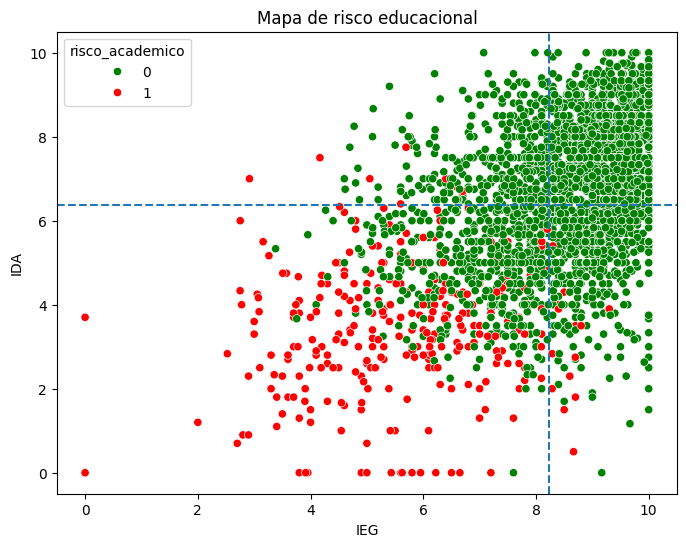

In [67]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="IEG",
    y="IDA",
    hue="risco_academico",
    palette=["green","red"]
)

plt.axhline(df["IDA"].mean(), linestyle="--")
plt.axvline(df["IEG"].mean(), linestyle="--")

plt.title("Mapa de risco educacional")

plt.show()

Analizando o nosso mapa de risco conseguimos ver que quando menor o IDA e o IEG, maior o risco educacional.

B) Outro insight seria identificar, precocemente, o risco de alunos cair de rendimento em seu desepenho. Para isso, identificamos os alunos que possuem, simultaneamente, desempenho nos indicadores IAN, IEG e IPS abaixo da mediana do grupo.

In [68]:
# Definindo limiares (mediana dos indicadores)
limiar_ian = df["IAN"].median()
limiar_ieg = df["IEG"].median()
limiar_ips = df["IPS"].median()

# Criando variável de risco educacional
df["RISCO_EDUCACIONAL"] = (
    (df["IAN"] < limiar_ian) &
    (df["IEG"] < limiar_ieg) &
    (df["IPS"] < limiar_ips)
)

df["RISCO_EDUCACIONAL"].value_counts()

,count
RISCO_EDUCACIONAL,
False,2823
True,22


In [69]:
# Filtrar o DataFrame para alunos com risco educacional
alunos_em_risco = df[df['RISCO_EDUCACIONAL'] == True]

# Calcular o INDE médio para estes alunos
media_inde_alunos_em_risco = alunos_em_risco['INDE'].mean()

print(f"O INDE médio dos {len(alunos_em_risco)} alunos com risco educacional é: {media_inde_alunos_em_risco:.2f}")

O INDE médio dos 22 alunos com risco educacional é: 5.50


In [70]:
# Calcular as medianas dos indicadores (limiar)
limiar_ian = df["IAN"].median()
limiar_ieg = df["IEG"].median()
limiar_ips = df["IPS"].median()

# Criação da variável Fatores de Risco para todos os estudantes
# Para cada aluno, conta quantos dos três indicadores (IAN, IEG, IPS) estão abaixo de suas respectivas medianas
df.loc[:, "FATORES_RISCO"] = (
    (df["IAN"] < limiar_ian).astype(int) +
    (df["IEG"] < limiar_ieg).astype(int) +
    (df["IPS"] < limiar_ips).astype(int)
)

print("Quantidade de Alunos por Fator de Risco")
print(df["FATORES_RISCO"].value_counts().sort_index())

Quantidade de Alunos por Fator de Risco
FATORES_RISCO
0     739
1    1415
2     669
3      22
Name: count, dtype: int64


Desta forma, podemos classificar os alunos por faotres de risco:

0 - Aluno sem risco;

1 - Risco leve;

2 - Risco moderado;

3 - Alto risco

Analisando o resultado, temos que:

739 alunos não apresentaram nenhum fator de risco (0).

1415 alunos apresentaram 1 fator de risco.

669 alunos apresentaram 2 fatores de risco.

22 alunos apresentaram 3 fatores de risco, ou seja, todos os indicadores (IAN, IEG e IPS) estão abaixo da mediana para este grupo.


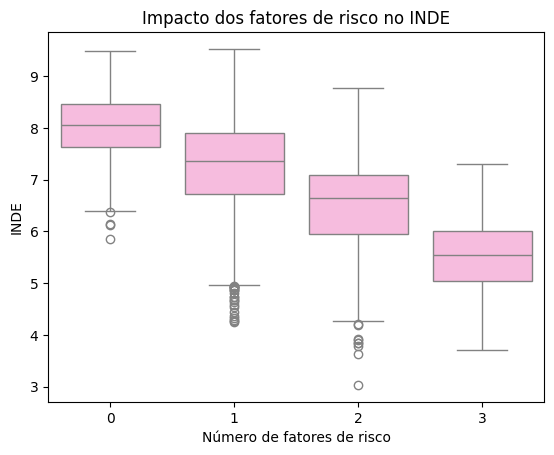

In [71]:
sns.boxplot(x="FATORES_RISCO", y="INDE", data=df, color='#ffb3df')

plt.title("Impacto dos fatores de risco no INDE")
plt.xlabel("Número de fatores de risco")
plt.ylabel("INDE")

plt.show()

No gráfico, verifica-se que quanto mais fatores de risco, menor o desempenho INDE do aluno.

Este identificador de risco funciona como um alerta, em que é possível tomar ações antecipadas de engajamento ou auxílio piscicossocial para que estes alunos apresentem melhores resultados nos próximos períodos.

A análise combinada dos indicadores IAN (adequação ao nível), IEG (engajamento) e IPS (aspectos psicossociais) permitiu identificar padrões associados ao risco educacional. Observou-se que alunos com baixos valores nesses três indicadores tendem a apresentar menores níveis de desenvolvimento educacional (INDE). Essa análise sugere a possibilidade de criação de um sistema de monitoramento baseado em múltiplos indicadores para identificar precocemente alunos em risco e direcionar intervenções pedagógicas e psicossociais.Este é o princípio base do sistema preditivo desenvolvido na questão 9.